In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from pathlib import Path
from scipy import signal
import re

In [2]:
DATA_DIR = Path("data/raw")

In [3]:
files = list(DATA_DIR.glob("*.hdf5"))

In [4]:
for file in files:
    print(file)

data/raw/H-H1_GWOSC_4KHZ_R1-1264316101-32.hdf5
data/raw/L-L1_GWOSC_4KHZ_R1-1264316101-32.hdf5


In [5]:
files[0].name

'H-H1_GWOSC_4KHZ_R1-1264316101-32.hdf5'

In [6]:
match = re.match(r".*-(\d+)-(\d+)\.hdf5$", files[0].name, flags=re.IGNORECASE)
file_start_gps = int(match.group(1)) # a group is a part of the matched text that’s captured by parentheses () in your regular expression.
file_duration = int(match.group(2))
print(files[0].name)
print(file_start_gps)
print(file_duration)

H-H1_GWOSC_4KHZ_R1-1264316101-32.hdf5
1264316101
32


In [7]:
path = files[0]
with h5py.File(path, "r") as f:
    print("Top-level keys:", list(f.keys()))
    print("\nInside 'Strain':", list(f["strain"].keys()))
    
    dset = f["strain"]["Strain"]
    print("Shape:", dset.shape)
    print("Data type:", dset.dtype)
    print("First 10 samples:", dset[:10])
    print("DSET Type:", type(dset))

Top-level keys: ['meta', 'quality', 'strain']

Inside 'Strain': ['GWOSCmeta', 'Strain']
Shape: (131072,)
Data type: float64
First 10 samples: [7.78093662e-21 1.18189890e-20 1.68268607e-20 1.09831546e-20
 4.77022809e-21 1.61422452e-20 1.93075218e-20 9.89761838e-21
 9.94420316e-21 1.36436917e-20]
DSET Type: <class 'h5py._hl.dataset.Dataset'>


In [8]:
with h5py.File(path, "r") as f:
    strain = f["strain"]["Strain"][:]

In [9]:
strain

array([ 7.78093662e-21,  1.18189890e-20,  1.68268607e-20, ...,
       -3.39502926e-20, -2.47413697e-20, -3.03693951e-20])

<AxesSubplot:ylabel='Count'>

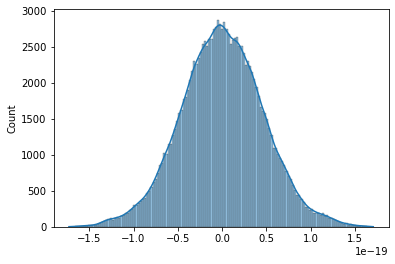

In [10]:
sns.histplot(data=strain, kde = True)

In [11]:
strain.mean()

-8.129713531576374e-24

### Skewness
Measures asymmetry

Right-skewed → long right tail

Left-skewed → long left tail
### Standard Deviation
Measures spread (how wide the data is)

Large std → values are far from the mean

Says nothing about shape

#### Examples

Data: symmetric but wide
→ High std, no skew

Data: narrow but with long right tail
→ Low std, but skewed

### Here:
It means the typical size of noise fluctuations is about 4.6610974429647713e-20 (in strain units).

~68% of values are within ±4.6610974429647713e-20

~95% within ±9.322194885929543e-20

In [18]:
strain.std()

4.6610974429647713e-20

In [19]:
4.6610974429647713e-20

4.6610974429647713e-20

In [20]:
4.6610974429647713e-20 * 2

9.322194885929543e-20

# Create 1-Second Windows

In [27]:
sampling_rate = 4096
window_size = sampling_rate
num_windows = len(strain)//window_size
strain_trimmed = strain[:num_windows * window_size]
strain_matrix = strain_trimmed.reshape(num_windows, window_size)
strain_matrix.shape

(32, 4096)

<AxesSubplot:ylabel='Count'>

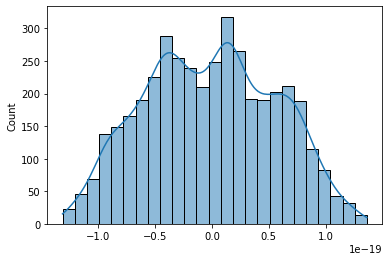

In [40]:
sns.histplot(strain_matrix[16], kde = True)

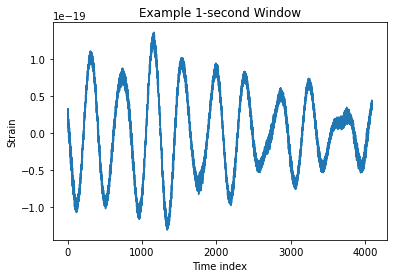

In [39]:
plt.plot(strain_matrix[16])
plt.title("Example 1-second Window")
plt.xlabel("Time index")
plt.ylabel("Strain")
plt.show()